# Spotify Playlist Explorer

Phase 1 demo: authenticate, pick a playlist, run Genre + Year analyses, render plots.

In [1]:
from pathlib import Path
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from spotify_project.cache import FileCache
from spotify_project.client import SpotifyClient
from spotify_project.analyzer import PlaylistAnalyzer

load_dotenv()
sns.set_theme(style='whitegrid')
cache = FileCache(root=Path('.cache') / 'api')
client = SpotifyClient.from_env(cache=cache)

## 1. Confirm authentication

In [2]:
user = client.current_user()
print(f"Hello, {user['display_name']} ({user['id']})")

Hello, ***REDACTED-NAME*** (***REDACTED-USERID***)


## 2. List your playlists

Spotify renamed `tracks` → `items` in their Feb 2026 migration. The `items` field is only present on playlists you own or collaborate on; for followed playlists, `tracks` reads as 0.

In [3]:
import pandas as pd
playlists = client.user_playlists()
summary = pd.DataFrame([
    {
        'id': p.get('id', ''),
        'name': p.get('name', '<unnamed>'),
        'tracks': (p.get('items') or {}).get('total', 0),
        'owner': p.get('owner', {}).get('display_name', ''),
    }
    for p in playlists
])
summary.head(20)

,id,name,tracks,owner
0,7CmreRETnY6t2MdHrIiaIA,Top 100 Doo Wop Hits 1953-1964,99,Hunter Pratt
1,36qmhWCGOAJt6pRScmHcyb,GTA 6 Soundtrack | 2026 GTA VI 🔥🎮,70,Magenta
2,3ebHKSjHujS4Tyt2KKP97R,Retrowave Synthwave,75,Cheerzo
3,0O3NMz7IEQJCLtO6tXLaq1,Surf Rock Classics,96,awaterslideaway
4,2ZHmECo8IsjfyWDKo0XwfC,Special Groove,37,Timothy Hale
5,5sDWiz1XZevt4T2qOOir50,Liens hochzeit,4,***REDACTED-NAME***
6,3v8PWRLiPHGPY0oHgkoZvV,Ben Böhmer [Not Live],20,***REDACTED-NAME***
7,5HMBUSi7dMH6N4l0ME6rzE,Chris Tmas,13,***REDACTED-NAME***
8,1oMfydMymnL1wQBxiZStDj,Loopthat,1,***REDACTED-NAME***
9,0x3U0VtCmPBEImdkpk177b,Rave In Your Grave,142,Timothy Hale


## 3. Pick a playlist and fetch it

Replace `PLAYLIST_ID` below with one of the IDs from the table above.

In [4]:
PLAYLIST_ID = '3v8PWRLiPHGPY0oHgkoZvV'
playlist = client.playlist(PLAYLIST_ID)
print(f"{playlist.name}: {len(playlist.tracks)} tracks")

Ben Böhmer [Not Live]: 20 tracks


## 4. Build the PlaylistAnalyzer and run analyses

In [5]:
analyzer = PlaylistAnalyzer.from_playlist(playlist)
results = analyzer.run_all()
for title, df in results.items():
    print(title)
    print(df.head(), end='\n\n')

Top Genres
Empty DataFrame
Columns: [genre, count]
Index: []

Release Year Distribution
   year  count
0  2016      1
1  2017      1
2  2018      2
3  2019      3
4  2020      1



## 5. Render plots

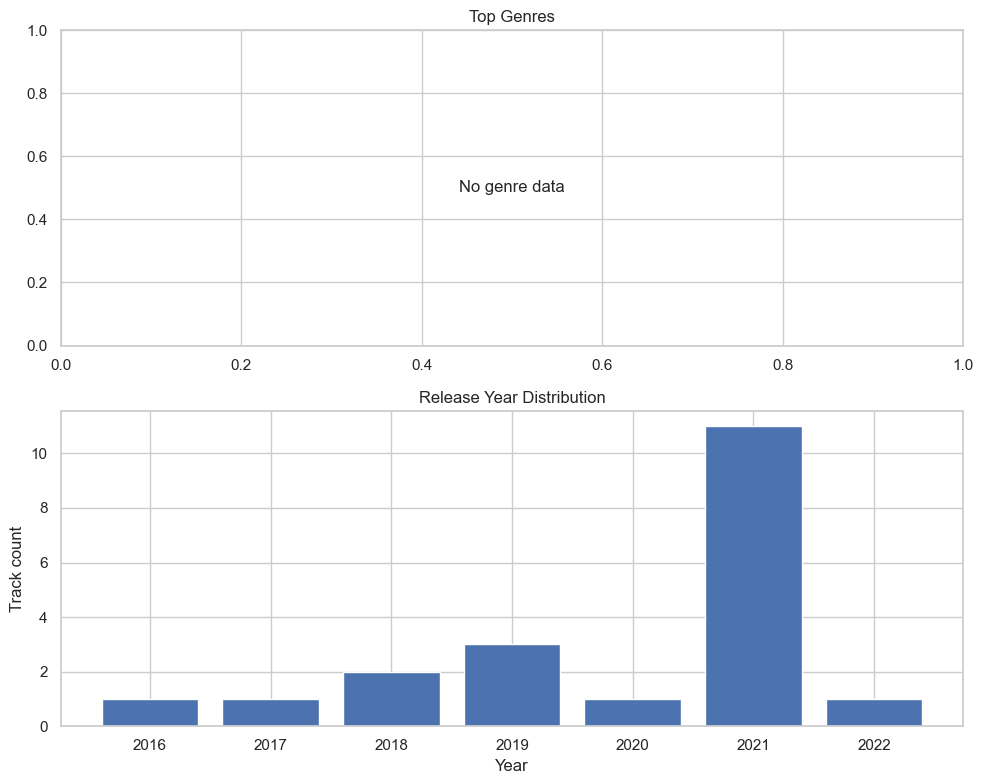

In [6]:
fig = plt.figure(figsize=(10, 8))
analyzer.plot_all(fig)
plt.show()